# Real World Classification

## Load data

Import the necessary libraries

In [ ]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

seed=40
np.random.seed(seed)

load the data

In [11]:
# Load data from the regularization demo CSV
df = pd.read_csv('data/NYCU_Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,7.0,NaN,4.700000,1.4,16.9,37.5,6.769877,6.755471,6.964281,...,0.466458,0.961982,-0.041964,-2.573335,-0.290155,1.346631,0.334072,0.303819,-1.318415,Iris-versicolor
1,2,6.4,3.2,4.500000,1.5,16.4,95.1,6.202714,6.129652,6.201464,...,-1.270085,1.283433,-1.155498,-0.295384,0.684086,-0.426519,0.113067,1.562539,0.095345,Iris-versicolor
2,3,6.9,NaN,4.900000,1.5,16.9,73.2,6.726317,6.762992,6.784647,...,0.562054,1.238704,0.345857,1.172525,0.320302,-0.563687,-1.514457,-0.179045,-0.577574,Iris-versicolor
3,4,5.5,2.3,5.085612,1.3,15.6,59.9,5.608292,5.529096,5.382254,...,-0.165898,0.914796,1.252364,-0.301381,-0.466333,-0.773040,-0.793858,0.483426,1.210299,Iris-versicolor
4,5,6.5,2.8,4.600000,1.5,16.4,15.6,6.300774,6.443553,6.274360,...,-0.602098,2.045948,-0.465691,0.862299,2.085633,2.047018,0.005283,0.506305,0.766709,Iris-versicolor


In [13]:
cols_with_missing = df.columns[df.isnull().any()]
report = df[cols_with_missing].agg(['median', 'std'])
print("Columns with missing values - Median and Standard Deviation:")
display(report)

Columns with missing values - Median and Standard Deviation:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength
median,6.300000,2.900000,5.085612,1.600000,16.300000
std,1.037115,0.389564,1.582807,0.706689,1.035228


## Data Preprocessing

In [14]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

def data_preprocessing(df):
    # transform label to bi-class
    df['Species'] = df['Species'].astype(str).str.strip()
    le = LabelEncoder()
    df['Species'] = le.fit_transform(df['Species'])

    feature_cols = [c for c in df.columns if c not in ['Id', 'Species']]

    # transform string to number
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # TODO: Replace the missing values using “Nearest Neighbors Imputation”
    # ---------- Start your code below ----------
    cols_with_missing = df.columns[df.isnull().any()].tolist()

    imputer = KNNImputer(n_neighbors=5)

    df[feature_cols] = imputer.fit_transform(df[feature_cols])

    print("Medain and Standard Deviation after Replacing Missing Values:")
    stats_report = df[cols_with_missing].agg(['median', 'std'])
    display(stats_report)

    # ---------- --------------------- ----------

    return df, feature_cols

df, feature_cols = data_preprocessing(df)

Medain and Standard Deviation after Replacing Missing Values:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength
median,6.300000,2.900000,5.035683,1.700000,16.300000
std,1.009275,0.372434,1.514955,0.694645,1.011012


In [15]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,250.500000,6.319840,2.837040,5.049883,1.684440,16.303440,46.745800,6.316422,6.323365,6.320980,...,0.068882,-0.029672,-0.015074,0.037059,0.082579,0.011686,0.077167,-0.034112,0.029674,0.5200
std,144.481833,1.009275,0.372434,1.514955,0.694645,1.011012,30.032428,1.009859,1.043500,1.024075,...,1.049557,1.046532,1.024190,0.995562,1.033822,1.011917,0.969005,0.949463,0.969047,0.5001
min,1.000000,3.000000,1.500000,0.500000,-1.000000,12.700000,0.600000,2.877573,2.944078,2.955459,...,-3.258345,-3.090824,-2.673773,-2.735569,-3.033392,-2.625754,-3.143116,-2.878216,-2.589544,0.0000
25%,125.750000,5.800000,2.630000,4.500000,1.300000,15.800000,18.500000,5.836615,5.801651,5.793089,...,-0.625022,-0.702388,-0.649046,-0.630572,-0.627218,-0.718793,-0.529432,-0.649448,-0.653394,0.0000
50%,250.500000,6.300000,2.900000,5.035683,1.700000,16.300000,44.000000,6.316422,6.310315,6.320980,...,0.076748,-0.047413,-0.044223,-0.022831,0.109614,-0.017135,0.112847,-0.019524,0.044542,1.0000
75%,375.250000,6.700000,3.040000,5.300000,2.000000,16.700000,73.200000,6.738205,6.797044,6.699885,...,0.806166,0.655584,0.641842,0.750853,0.816614,0.743847,0.751684,0.631034,0.674469,1.0000
max,500.000000,9.600000,4.000000,9.200000,4.300000,19.700000,98.700000,10.032204,10.146460,10.262641,...,3.333114,3.888629,3.174867,3.109433,3.507325,3.100138,2.626066,2.515151,3.254291,1.0000


## Data Exploration

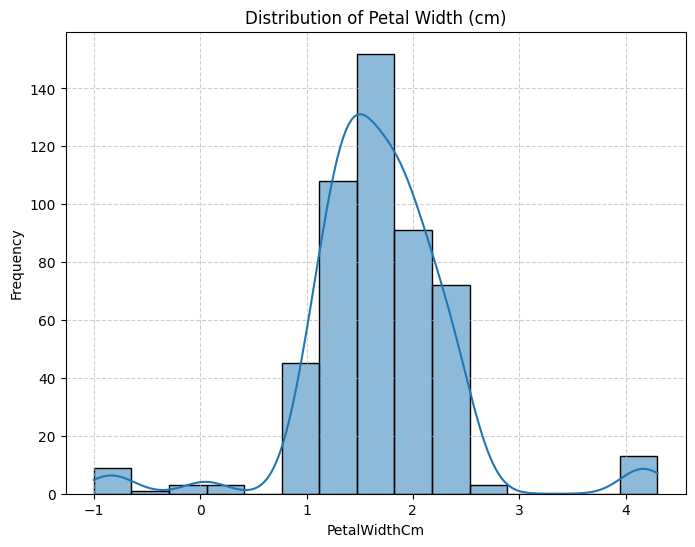

4(b) Largest positive correlation feature: PetalWidthCompactness

4(c) Top 5 features with strongest negative correlations:
SepalWidthMajorAxis     -0.096350
SepalGlossIndex         -0.095200
SepalWidthCompactness   -0.088496
SepalWidthCurvature     -0.081334
SepalWidthMinorAxis     -0.074392
dtype: float64


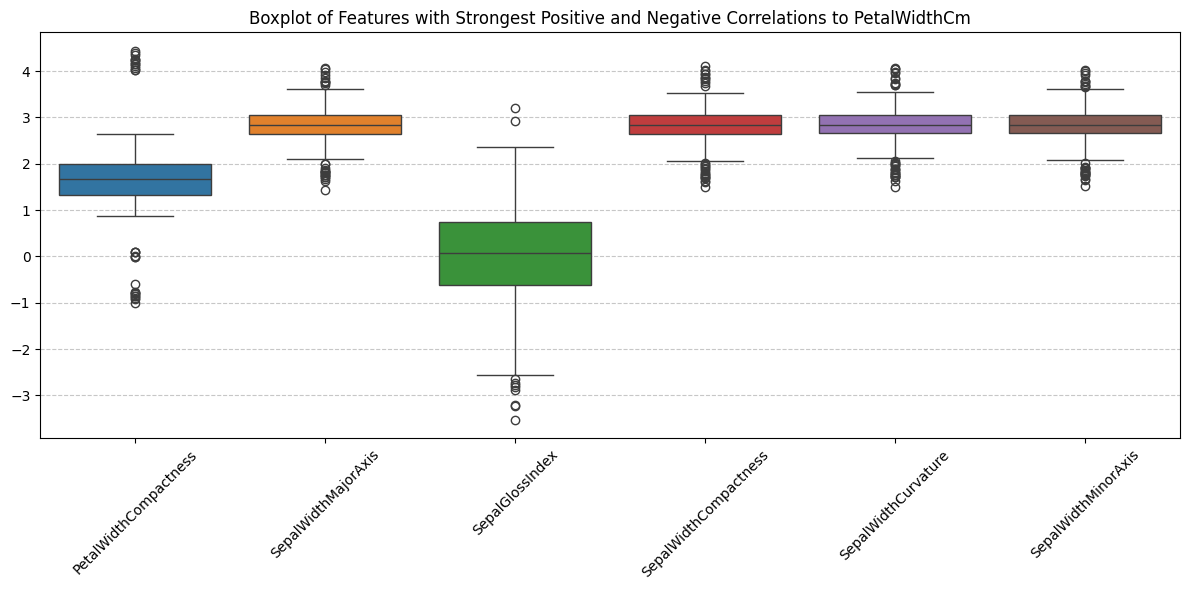

In [19]:
from sklearn.feature_selection import r_regression

# TODO: Complete the 4. Data Exploration
# 4a
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.histplot(df['PetalWidthCm'], bins=15, kde=True)
plt.title('Distribution of Petal Width (cm)')
plt.xlabel('PetalWidthCm')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


target = "PetalWidthCm"
exclude_cols = ["PetalWidthCm", "Species", "Id"]
feature_cols_for_corr = [c for c in df.columns if c not in exclude_cols]

correlations = r_regression(df[feature_cols_for_corr], df[target])
corr_series = pd.Series(correlations, index=feature_cols_for_corr)

# 4(b)
largest_pos_feature = corr_series.idxmax()
print(f"4(b) Largest positive correlation feature: {largest_pos_feature}")

# 4(c)
top_5_negative_features = corr_series.sort_values().head(5)
print("\n4(c) Top 5 features with strongest negative correlations:")
print(top_5_negative_features)

# 4(d)
selected_features = [largest_pos_feature] + top_5_negative_features.index.tolist()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[selected_features])
plt.title("Boxplot of Features with Strongest Positive and Negative Correlations to PetalWidthCm")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('correlation_boxplots.png')
plt.show()


## Model Training

### Prepare the data

In [20]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

# normalize the data to [0,1]
for col in feature_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    if col_max > col_min:
        df[col] = (df[col] - col_min) / (col_max - col_min)
    else:
        df[col] = 0.0

X = df[feature_cols].values.astype(float)
y = df['Species'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,0.606061,0.608,0.482759,0.452830,0.600000,0.376147,0.544026,0.529185,0.548614,...,0.565095,0.580677,0.449986,0.027756,0.419409,0.693758,0.602718,0.589990,0.217516,0
1,2,0.515152,0.680,0.459770,0.471698,0.528571,0.963303,0.464754,0.442295,0.444221,...,0.301642,0.626733,0.259595,0.417482,0.568359,0.384086,0.564410,0.823373,0.459439,0
2,3,0.590909,0.616,0.505747,0.471698,0.600000,0.740061,0.537937,0.530229,0.524031,...,0.579598,0.620325,0.516296,0.668622,0.512741,0.360130,0.282303,0.500461,0.344289,0
3,4,0.378788,0.320,0.527082,0.433962,0.414286,0.604485,0.381672,0.358911,0.332111,...,0.469160,0.573916,0.671291,0.416456,0.392474,0.323568,0.407208,0.623292,0.650231,0
4,5,0.530303,0.520,0.471264,0.471698,0.528571,0.152905,0.478459,0.485877,0.454197,...,0.402983,0.735985,0.377538,0.615546,0.782640,0.816078,0.545727,0.627534,0.574324,0


### Train the model!

50. Training loss: 0.6192229675550639, Val loss:0.6387339171797572
100. Training loss: 0.5979091328910923, Val loss:0.6238920902494233
150. Training loss: 0.5812650420168968, Val loss:0.612622557656859
200. Training loss: 0.5679827993268195, Val loss:0.6039318894908268
250. Training loss: 0.5571858255876307, Val loss:0.5971444430979668
300. Training loss: 0.5482708567526591, Val loss:0.59178857989705
350. Training loss: 0.5408117331839131, Val loss:0.5875271116871134
400. Training loss: 0.5344999386168847, Val loss:0.5841138047798571
450. Training loss: 0.5291070807888374, Val loss:0.5813654836364933
500. Training loss: 0.524460662779445, Val loss:0.5791436781671646
550. Training loss: 0.5204280628046019, Val loss:0.577342251554659
600. Training loss: 0.5169056942810414, Val loss:0.5758788683267104
650. Training loss: 0.5138115085968704, Val loss:0.57468898760961
700. Training loss: 0.5110797027848409, Val loss:0.5737215545999529
750. Training loss: 0.5086569127317132, Val loss:0.57293

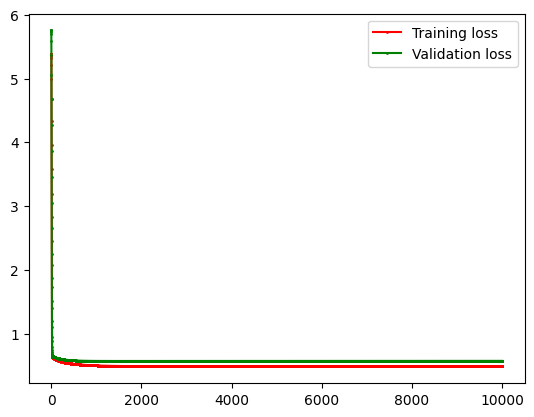

Model parameters (weights): [[-0.6736172 ]
 [ 0.48849652]
 [ 0.179458  ]
 [-0.01432622]
 [ 0.80333745]
 [ 0.31657614]
 [ 0.20007635]
 [ 0.28825311]
 [ 0.32984404]
 [ 0.52401411]
 [ 0.40304197]
 [ 0.37827534]
 [ 0.47899858]
 [ 0.02790797]
 [-0.14438477]
 [ 0.10533422]
 [ 0.24353204]
 [ 0.19134209]
 [ 0.13862588]
 [ 0.13162341]
 [ 0.22633432]
 [ 0.27839164]
 [ 0.15181066]
 [ 0.24553839]
 [ 0.16545861]
 [ 0.8529222 ]
 [ 0.86820804]
 [ 0.87376073]
 [ 0.88927071]
 [ 0.91004762]
 [ 0.87391149]
 [-0.71611561]
 [ 0.33682521]
 [-0.22246403]
 [-0.00507796]
 [-0.36644352]
 [ 0.08087238]
 [-0.45789113]
 [-1.16842485]
 [-0.1859957 ]
 [-0.50217185]
 [-0.21872532]
 [-0.56235885]
 [-0.43939383]
 [ 0.10080915]
 [-0.24072012]
 [-0.17200155]
 [-0.13675272]
 [-0.34467403]
 [-0.35870215]
 [-0.21152253]
 [-0.11000756]
 [-0.08478125]
 [-0.30106099]
 [-0.12437904]
 [ 0.05426102]
 [-0.41635178]
 [-0.58111666]
 [-0.24637554]
 [-0.08877881]
 [-0.55101013]
 [ 0.10701598]
 [ 0.17933916]
 [-0.6301576 ]
 [-0.1842469

In [48]:
from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid


# Model configuration
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

# for L2 Regularization, set is_reg=True, reg_type='l2', reg_lambda=0.01/1/100
np.random.seed(seed)
model = LinearModel(dim=X_train.shape[1], is_reg=True, loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn)
model.fit(X_train, y_train,lr=0.1, n_iteration =10000,val_ratio=0.2, reg_type='l2', reg_lambda=1)

# print model parameters
print("Model parameters (weights):", model.W)
# sum of absolute values of weights
print("Sum of absolute values of weights:", np.sum(np.abs(model.W)))

## Metrics

Model Evaluation
Accuracy  : 0.4933
Precision : 0.0000
Recall    : 0.0000
F1-score  : 0.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


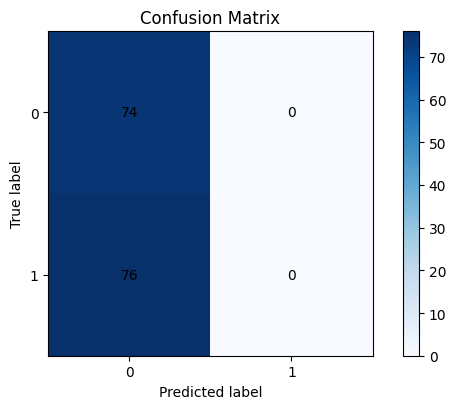

{'Accuracy': 0.49333333333333335,
 'Precision': 0.0,
 'Recall': 0.0,
 'F1-score': 0.0}

In [47]:
# use evaluate_binary_classifier to evaluate the model on the test set
from model.metrics import evaluate_binary_classifier

y_pred = model.predict(X_test)
evaluate_binary_classifier(y_test, y_pred)